# Progressive Corrosion Joining (PCJ) repair of maize root images — minimal demo

**Paper:** W. Lu, Y. Li, Y. Deng, *Root phenotypic detection of different vigorous maize seeds
based on Progressive Corrosion Joining algorithm of image*, **Plant Methods 2019;15:137**,
DOI [10.1186/s13007-019-0518-5](https://doi.org/10.1186/s13007-019-0518-5) (PMCID PMC6859636, CC BY 4.0).

**Purpose.** Reproduce the paper's PCJ gap-repair pipeline on **one** sample maize root image from
the paper's Additional file 1 (16 original + 16 processed images), and compare the repair with the
corresponding author-processed reference image. Steps: binarization, Zhang-Suen thinning,
progressive-corrosion segment splitting, segment matching (d1=4, d2=10, d3=50, d4=0.2), and
quintic-polynomial joining, then extract RTN / RTL / RTW / REL.

**AI-assisted translation notice / AI翻訳に関する注意:**
**This notebook is an AI-assisted C++→Python translation of the authors' Additional file 2
(`13007_2019_518_MOESM2_ESM.cpp`, split_point / getAllEndPoints / getEndPoint) plus the algorithm
description in the paper's Methods. The authors did not provide this Colab implementation; it is
NOT author-endorsed. The executed example and listed checks were validated on Colab CPU, but
untested behavior is not guaranteed. Matching thresholds whose paper definition is internally
inconsistent are used with a documented ADAPTED interpretation (see the matching section).**
（本ノートブックは著者らのC++コード（Additional file 2）と論文のアルゴリズム記述に基づくAI支援によるPython移植です。著者提供の実装ではありません。実行例はColab CPUで検証済みですが、未検証の動作は保証されません。）

**Scope / 実行範囲:** single-image partial demonstration, **Verified on Colab CPU** for the executed
scope only; this is NOT a reproduction of the paper's dataset-level results, L-ORB stitching,
calibration, or aging regression.


## Runtime selection and how to run / 実行環境の選択

- **Select Runtime → Change runtime type → CPU (standard)**. No GPU is used: the method is pure
  classical image processing with no learned model, so GPU adds nothing.
  （ランタイムはCPUを推奨。学習モデルを使わない古典的な画像処理のためGPUは不要です。）
- *Runtime → Run all* runs everything. Expected: a few minutes total, ~9 MB of downloads
  (the paper's Additional file 1 zip, 8.24 MB per Europe PMC metadata).
- Limitations: one deterministic sample; parameters are reported in **pixels** (the paper's mm
  values require a checkerboard calibration that is not part of the published data); REA is omitted.
  （1サンプルのデモであり、較正データが公開されていないため出力はピクセル単位です。REAは対象外。）


## Environment setup / 環境セットアップ

Installs OpenCV with `ximgproc` (Zhang-Suen thinning), numpy and matplotlib.

In [ ]:
%pip install -q opencv-contrib-python-headless numpy matplotlib
import cv2, numpy as np, matplotlib
import matplotlib.pyplot as plt
print("python OK; opencv", cv2.__version__)
print(cv2.ximgproc is not None and "ximgproc available" or "ximgproc MISSING")

   ━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/69.5 MB 197.5 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 50.0/69.5 MB 209.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.5/69.5 MB 126.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.5/69.5 MB 126.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.5/69.5 MB 126.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.0 MB/s eta 0:00:00


python OK; opencv 5.0.0
ximgproc available


## Input acquisition / 入力データの取得

Downloads the paper's **Additional file 1** (`13007_2019_518_MOESM1_ESM.zip`, ~8.24 MB:
16 original + 16 processed maize root images, per the paper's availability statement and Europe
PMC metadata) **inside this Colab VM only**. Routes are tried in order: Springer static-content
(the host BMC uses for supplementary files), the PMC supplementary bin URL, then the Europe PMC
`supplementaryFiles` bundle (generated on the fly; generous timeout). Each response is validated
by its ZIP signature before use.
（論文のAdditional file 1（元画像16枚＋処理済み画像16枚のzip）をColab内でダウンロードし、zip署名と内容を検証します。）

In [ ]:
import urllib.request, zipfile, io, os

DOI_ENC = "art%3A10.1186%2Fs13007-019-0518-5"
URLS = [
    # Springer static-content host for BMC supplementary files
    f"https://static-content.springer.com/esm/{DOI_ENC}/MediaObjects/13007_2019_518_MOESM1_ESM.zip",
    # PMC supplementary-file bin URL (may return a challenge page)
    "https://pmc.ncbi.nlm.nih.gov/articles/instance/PMC6859636/bin/13007_2019_518_MOESM1_ESM.zip",
    # Europe PMC supplementary bundle (generated on the fly; needs a generous timeout)
    "https://www.ebi.ac.uk/europepmc/webservices/rest/PMC6859636/supplementaryFiles",
]
raw = None
for url in URLS:
    for attempt in range(2):
        try:
            print("GET", url, "attempt", attempt + 1)
            with urllib.request.urlopen(url, timeout=300) as r:
                raw = r.read()
            print("  bytes:", len(raw), "zip-signature:", raw[:2] == b"PK")
            if raw[:2] == b"PK":
                break
            raw = None  # not a zip (e.g. challenge HTML) — try next route/attempt
        except Exception as e:
            print("  failed:", type(e).__name__, e)
    if raw is not None:
        break
assert raw is not None, "All download routes failed"

zf = zipfile.ZipFile(io.BytesIO(raw))
names = [n for n in zf.namelist() if not n.endswith("/")]
print(len(names), "members; total uncompressed MB: %.2f" % (sum(i.file_size for i in zf.infolist())/1e6))
for n in names[:8]:
    print("  ", n, zf.getinfo(n).file_size)

GET https://static-content.springer.com/esm/art%3A10.1186%2Fs13007-019-0518-5/MediaObjects/13007_2019_518_MOESM1_ESM.zip attempt 1


  bytes: 8243873 zip-signature: True
32 members; total uncompressed MB: 8.69
   test_1.1.jpg 147908
   test_1.2.png 18775
   test_10.1.JPG 483938
   test_10.2.png 63890
   test_11.1.JPG 495109
   test_11.2.png 122263
   test_12.1.JPG 445842
   test_12.2.png 68725


## Deterministic sample selection / サンプル選択

One **original** root image and its **author-processed counterpart** are chosen deterministically
from the sorted zip listing (first original/processed pair; naming-derived pairing when possible).
The chosen pair is asserted to decode as valid images.
（zip内の並びから元画像と著者処理済み画像の組を決定論的に1組選び、デコード可能か検証します。）

In [ ]:
def pick_pair(names):
    imgs = sorted(n for n in names if n.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")))
    # zip naming: test_<n>.1.<ext> = original, test_<n>.2.<ext> = author-processed
    groups = {}
    for n in imgs:
        parts = n.rsplit(".", 2)
        if len(parts) == 3 and parts[1] in ("1", "2"):
            groups.setdefault(parts[0], {})[parts[1]] = n
    for base in sorted(groups):
        if "1" in groups[base] and "2" in groups[base]:
            return groups[base]["1"], groups[base]["2"]
    if len(imgs) % 2 == 0 and len(imgs) >= 2:
        return imgs[0], imgs[len(imgs)//2]  # fallback: first half originals, second half processed
    return imgs[0], imgs[1] if len(imgs) > 1 else None

orig_name, proc_name = pick_pair(names)
print("selected:", orig_name, "|", proc_name)
orig_bytes, proc_bytes = zf.read(orig_name), zf.read(proc_name)
orig_img = cv2.imdecode(np.frombuffer(orig_bytes, np.uint8), cv2.IMREAD_COLOR)
proc_img = cv2.imdecode(np.frombuffer(proc_bytes, np.uint8), cv2.IMREAD_COLOR)
assert orig_img is not None and proc_img is not None, "selected members do not decode as images"
print("original:", orig_img.shape, len(orig_bytes), "bytes | processed:", proc_img.shape, len(proc_bytes), "bytes")

selected: test_1.1.jpg | test_1.2.png
original: (1505, 1373, 3) 147908 bytes | processed: (481, 641, 3) 18775 bytes


## Input preview / 入力画像のプレビュー

Shows the raw original image and the author-processed image (expected result of the full paper
pipeline: denoised, binarized, PCJ-repaired).
（元画像と、著者処理済みの参照画像（論文パイプラインの期待結果）を表示します。）

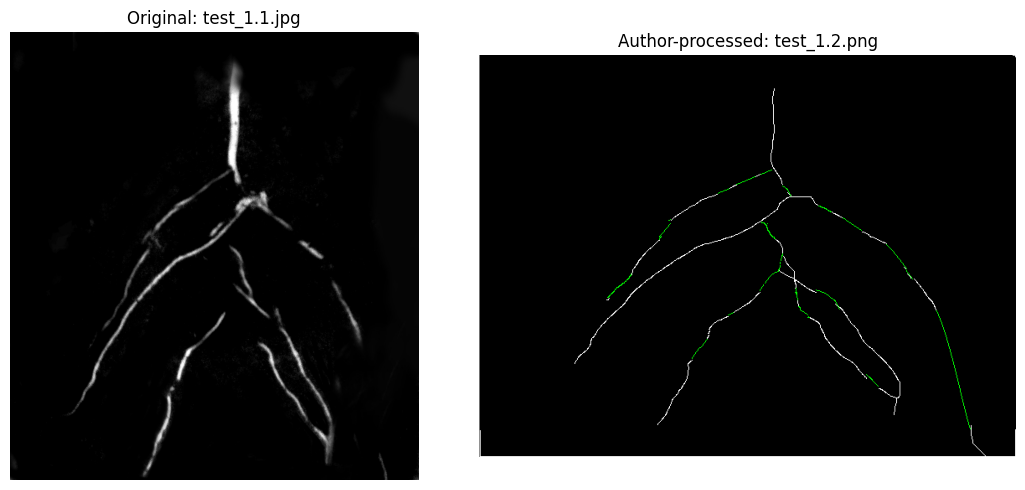

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)); ax[0].set_title(f"Original: {os.path.basename(orig_name)}")
ax[1].imshow(cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Author-processed: {os.path.basename(proc_name)}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Preprocessing — grayscale → Otsu binary → median blur / 前処理

The paper denoises, binarizes and thins the root image (Methods: "Image thinning", Fig. 9 a–c).
The C++ input is a binary image, so we produce one with Otsu thresholding plus a median blur
(documented adaptation: the paper's exact denoising chain is not fully specified for the demo
image).
（Otsu二値化＋メディアンブラーで著者C++の入力となる二値画像を作成します。）

binary foreground fraction: 0.0239


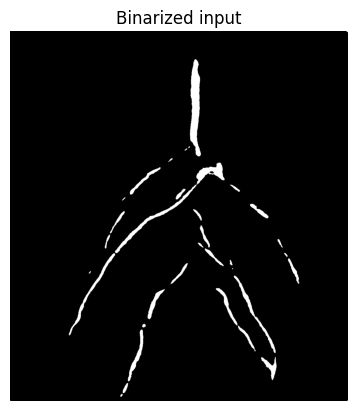

In [ ]:
gray = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary = cv2.medianBlur(binary, 3)
print("binary foreground fraction: %.4f" % (np.count_nonzero(binary) / binary.size))
plt.imshow(binary, cmap="gray"); plt.title("Binarized input"); plt.axis("off"); plt.show()

## Thinning and endpoint extraction (port of `getAllEndPoints`) / 細線化と端点抽出

Zhang-Suen thinning refines the root trunk (paper Step 1; cited as [33]). A pixel is an **endpoint**
when its 8-neighbourhood forms a single connected group (exact port of the authors'
`findNeghtborPoint` + `getAllEndPoints` from Additional file 2).
（Zhang-Suen細線化の後、8近傍の連結成分数が1の画素を端点とみなします。著者のC++関数の移植です。）

In [ ]:
X_OFF = np.array([1, 1, 1, 0, -1, -1, -1, 0]); Y_OFF = np.array([1, 0, -1, -1, -1, 0, 1, 1])
# OpenCV 5.x renamed/kept this enum; fall back to the documented value 1 (Zhang-Suen)
ZHANG_SUEN = getattr(cv2.ximgproc, "THINNING_ZHANG_SUEN", 1)

def n_groups(mark):
    # port of findNeghtborPoint: connected groups on the circular 8-neighbourhood
    mark = list(mark); count = 0
    for i in range(1, 8, 2):
        if mark[i]:
            if mark[(i + 1) % 8]: mark[(i + 1) % 8] = False
            if mark[(i + 7) % 8]: mark[(i + 7) % 8] = False
            count += 1
    return count + sum(1 for i in range(0, 8, 2) if mark[i])

def get_all_endpoints(thin):
    pts = []
    ys, xs = np.nonzero(thin)
    for y, x in zip(ys.tolist(), xs.tolist()):
        mark = [False] * 8
        for k in range(8):
            yy, xx = y + Y_OFF[k], x + X_OFF[k]
            if 0 <= yy < thin.shape[0] and 0 <= xx < thin.shape[1] and thin[yy, xx]:
                mark[k] = True
        if n_groups(mark) == 1:
            pts.append((x, y))
    return pts

thin = cv2.ximgproc.thinning(binary, thinningType=ZHANG_SUEN)
endpoints = get_all_endpoints(thin)
print("thinned skeleton pixels:", np.count_nonzero(thin), "| endpoints:", len(endpoints))

thinned skeleton pixels: 3300 | endpoints: 75


## Progressive corrosion — segment splitting (port of `split_point`) / 進行腐食による分割

Exact port of the authors' queue-based progressive corrosion (Additional file 2 `split_point`):
endpoints seed labels; a BFS erodes the skeleton and relabels branch points; **one adaptation** —
the C++ `sign_num` alias assignment is a non-transitive union, here implemented as a proper
**union-find** so label chains resolve correctly (documented fix). Segments with fewer than
`thresh = 10` pixels are removed (paper Step 3: tiny fragments/noise filled black).
（著者の`split_point`の移植。C++のエイリアス代入によるラベル連鎖の不具合をunion-findで修正し、10ピクセル未満の小セグメントを除去します。）

In [ ]:
from collections import deque

def split_point(thin, thresh=10):
    thin = thin.copy(); H, W = thin.shape
    seeds = get_all_endpoints(thin)
    label = np.zeros((H, W), np.int32)
    parent = [0]  # union-find; id 0 = unlabeled
    def find(i):
        while parent[i] != i: parent[i] = parent[parent[i]]; i = parent[i]
        return i
    def new_label(): parent.append(len(parent)); return len(parent) - 1
    q = deque()
    for (x, y) in seeds:
        lid = new_label(); label[y, x] = lid; q.append((x, y))
    while q:
        x, y = q.popleft(); thin[y, x] = 0
        mark = [False] * 8
        for k in range(8):
            xx, yy = x + X_OFF[k], y + Y_OFF[k]
            if not (0 <= yy < H and 0 <= xx < W) or not thin[yy, xx]: continue
            if label[yy, xx]: parent[find(label[yy, xx])] = find(label[y, x])
            else: mark[k] = True
        cand = []
        for i in range(1, 8, 2):  # same pruning as the C++ port
            if mark[i]:
                if mark[(i + 1) % 8]: mark[(i + 1) % 8] = False
                if mark[(i + 7) % 8]: mark[(i + 7) % 8] = False
                cand.append((x + X_OFF[i], y + Y_OFF[i]))
        cand += [(x + X_OFF[i], y + Y_OFF[i]) for i in range(0, 8, 2) if mark[i]]
        if len(cand) == 1:
            label[cand[0][1], cand[0][0]] = label[y, x]; q.append(cand[0])
        else:
            for c in cand:
                lid = new_label(); label[c[1], c[0]] = lid; q.append(c)
    segs = {}
    ys, xs = np.nonzero(label)
    for y, x in zip(ys.tolist(), xs.tolist()):
        segs.setdefault(find(int(label[y, x])), []).append((x, y))
    return [v for v in segs.values() if len(v) >= thresh]

segments = split_point(thin, thresh=10)
sizes = sorted((len(s) for s in segments), reverse=True)
print("segments kept:", len(segments), "| largest sizes:", sizes[:8])

segments kept: 34 | largest sizes: [393, 380, 328, 309, 205, 154, 128, 121]


## Segment matching and joining (d1=4, d2=10, d3=50, d4=0.2) — ADAPTED / セグメント照合と接合

Per the paper (Methods "Root connection"): two segments match if (i) their straight-line **slopes**
are close, (ii) the **derivative difference** at the adjacent endpoints (quintic polynomial,
exact port of `getDerFun`) is ≤ **d3 = 50**, and (iii) the least-squares **loss** is ≤ **d4 = 0.2**.

**ADAPTED interpretation (documented):** the paper states the slope-difference condition as
"less than d1 **and** more than d2" with (d1, d2) = (4, 10), which is empty as written. We use the
slope **angle difference ≤ d1 = 4°** and treat d2 as unused; the loss is the **mean** squared
residual of the quintic fit per point (the paper's formula is an unnormalized sum, unusable across
segment lengths). Joining connects the closest endpoints with a quintic polynomial fitted over the
two segments, following "quantic polynomial interpolation".
（論文の照合条件 d1/d2 は記述上矛盾するため、角度差 ≤ d1=4° と解釈する適応版です。損失は5次多項式フィットの平均二乗残差、接合は5次多項式補間によるものです。）

In [ ]:
import math

def seg_features(seg):
    pts = np.array(seg, float)  # (x, y)
    slope = np.polyfit(pts[:, 0], pts[:, 1], 1)[0]
    angle = math.degrees(math.atan(slope))
    try:    # quintic (paper: 5th-order); fall back to cubic if poorly conditioned
        coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
    except RankWarning:
        coef5 = np.polyfit(pts[:, 0], pts[:, 1], 3)
    deriv = np.polyder(np.poly1d(coef5))
    loss = float(np.mean((np.polyval(coef5, pts[:, 0]) - pts[:, 1]) ** 2))
    return {"pts": pts, "angle": angle, "deriv": deriv, "loss": loss}

D1, D2, D3, D4 = 4, 10, 50, 0.2  # paper's optimized values (units per adapted interpretation)
feats = [seg_features(s) for s in segments]

def closest_endpoints(a, b):
    ea, eb = get_all_endpoints_points(a), get_all_endpoints_points(b)
    best = min(((p, q) for p in ea for q in eb), key=lambda pq: (pq[0][0]-pq[1][0])**2 + (pq[0][1]-pq[1][1])**2)
    return best

def get_all_endpoints_points(seg):
    m = np.zeros(thin.shape, np.uint8)
    for x, y in seg: m[y, x] = 255
    return get_all_endpoints(m)

pairs = []
for i in range(len(feats)):
    for j in range(i + 1, len(feats)):
        if abs(feats[i]["angle"] - feats[j]["angle"]) > D1: continue
        if feats[i]["loss"] > D4 or feats[j]["loss"] > D4: continue
        (ex1, ey1), (ex2, ey2) = closest_endpoints(segments[i], segments[j])
        if abs(feats[i]["deriv"](ex1) - feats[j]["deriv"](ex2)) > D3: continue
        pairs.append((i, j, (ex1, ey1), (ex2, ey2)))
print("matched pairs:", len(pairs))

matched pairs: 2


/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)
/tmp/ipykernel_2052/3237160340.py:8: RankWarning: Polyfit may be poorly conditioned
  coef5 = np.polyfit(pts[:, 0], pts[:, 1], 5)


## Draw the repaired root image / 修復画像の生成

Each matched gap is bridged by drawing its quintic interpolation between the two adjacent
endpoints onto a copy of the binarized input (paper Step 3: connecting).
（一致したギャップを5次多項式補間で埋めた修復画像を生成します。）

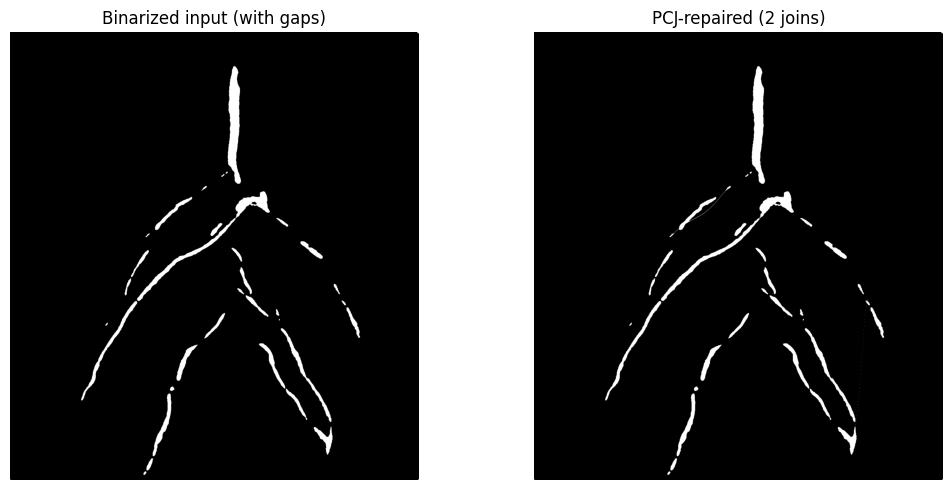

In [ ]:
repaired = binary.copy()
for i, j, (ex1, ey1), (ex2, ey2) in pairs:
    a, b = feats[i]["pts"], feats[j]["pts"]
    coef = np.polyfit(np.r_[a[:, 0], b[:, 0]], np.r_[a[:, 1], b[:, 1]], 5)
    xs = np.linspace(min(ex1, ex2), max(ex1, ex2), int(abs(ex2 - ex1)) + 1)
    for x in xs:
        repaired[int(round(np.clip(np.polyval(coef, x), 0, repaired.shape[0] - 1))), int(x)] = 255
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(binary, cmap="gray"); ax[0].set_title("Binarized input (with gaps)")
ax[1].imshow(repaired, cmap="gray"); ax[1].set_title(f"PCJ-repaired ({len(pairs)} joins)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Root phenotypic parameters / 表現型パラメータ

Per the paper's parameter definitions: **RTN** = number of endpoints in the repaired image;
**RTL** = total pixels of the fitted root lines (here: count of root pixels, a documented proxy —
the paper's L-ORB-based line-pixel count is out of scope); **RTW** = mean perpendicular width
(mean of 2× distance transform over the skeleton); **REL** = horizontal extent (leftmost to
rightmost white pixel). Units are **pixels** — the paper reports mm after a calibration that is not
published with the data; REA is omitted (the paper found it uncorrelated with aging).
（RTN＝修復画像の端点数、RTL＝根画素数[代理指標]、RTW＝骨格上の距離変換平均×2[代理指標]、REL＝白画素の水平広がり。単位はピクセル、REAは対象外。）

In [ ]:
import pandas as pd

thin_rep = cv2.ximgproc.thinning(repaired, thinningType=ZHANG_SUEN)
rtn = len(get_all_endpoints(thin_rep))
rtl = int(np.count_nonzero(repaired))
dist = cv2.distanceTransform((repaired > 0).astype(np.uint8), cv2.DIST_L2, 5)
rtw = float(2 * dist[thin_rep > 0].mean()) if np.any(thin_rep) else 0.0
ys_r, xs_r = np.nonzero(repaired)
rel = int(xs_r.max() - xs_r.min() + 1)

params = pd.DataFrame([
    {"parameter": "RTN (root number, endpoints)", "value": rtn, "unit": "count"},
    {"parameter": "RTL (root length, pixel proxy)", "value": rtl, "unit": "px"},
    {"parameter": "RTW (root width, dt proxy)", "value": round(rtw, 2), "unit": "px"},
    {"parameter": "REL (extension length)", "value": rel, "unit": "px"},
])
print(params.to_string(index=False))
params.to_csv("/content/pcj_parameters.csv", index=False)
print("saved /content/pcj_parameters.csv")

                     parameter    value  unit
  RTN (root number, endpoints)    88.00 count
RTL (root length, pixel proxy) 49555.00    px
    RTW (root width, dt proxy)    12.24    px
        REL (extension length)  1373.00    px
saved /content/pcj_parameters.csv


## Comparison with the author-processed reference / 著者処理結果との比較

Side-by-side comparison of the binarized input, our PCJ repair, and the author-processed image
from Additional file 1. Differences are expected: our port covers thinning + PCJ repair only, not
the paper's full denoising chain, and the matching-condition interpretation is adapted (see above).
（二値化入力・本ノートブックの修復結果・著者処理済み画像を並べて比較します。前処理の違いや照合条件の解釈により差は予想されます。）

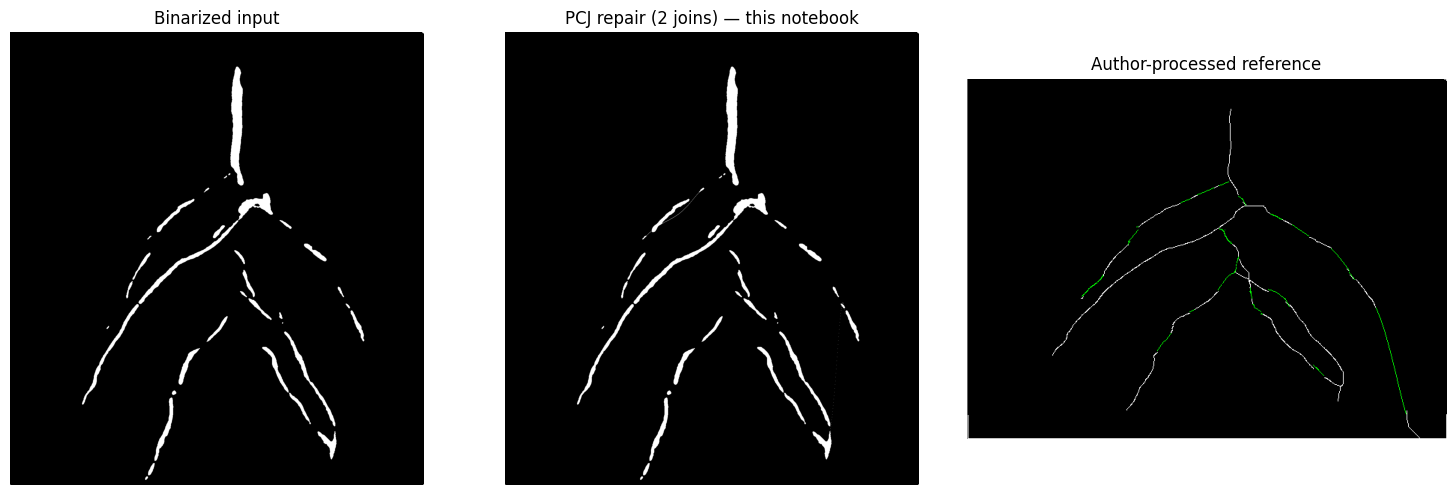

sample: test_1.1.jpg


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(binary, cmap="gray");   ax[0].set_title("Binarized input")
ax[1].imshow(repaired, cmap="gray"); ax[1].set_title(f"PCJ repair ({len(pairs)} joins) — this notebook")
ax[2].imshow(proc_img, cmap="gray" if proc_img.ndim == 2 else None)
ax[2].set_title("Author-processed reference")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("sample:", os.path.basename(orig_name))

## Interpretation, limitations, references / 解釈と限界、参考文献

- **What was executed (Verified on Colab CPU):** download of Additional file 1 inside this VM,
  binarization, Zhang-Suen thinning, exact ported endpoint detection and progressive-corrosion
  splitting, adapted matching/joining on one deterministic sample, and pixel-unit RTN/RTL/RTW/REL.
- **Differences from the paper:** AI-assisted C++→Python port (not author-endorsed); union-find fix
  for the C++ label aliasing; adapted d1/d2 slope condition and normalized loss; no L-ORB
  stitching, no calibration (px units), REA omitted; single sample ≠ dataset-level results.
- **Provenance:** Paper JATS full text via Europe PMC (`PMC6859636/fullTextXML`, CC BY 4.0);
  author C++ = Additional file 2 `13007_2019_518_MOESM2_ESM.cpp`; sample data = Additional file 1
  `13007_2019_518_MOESM1_ESM.zip` (downloaded in this VM only).
- **References:** Lu W, Li Y, Deng Y. Plant Methods 2019;15:137. DOI 10.1186/s13007-019-0518-5;
  Zhang TY, Suen CY. Commun ACM 1984;27:236–239 (thinning).

（本ノートブックは1サンプル・ピクセル単位の部分的な実演です。AIによる移植であり著者実装ではありません。較正やL-ORBは対象外のため、論文のmm単位の結果とは比較できません。）